# Deep Learning Project : Classifiers

## Imports

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import cv2
import os
import re

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch.nn as nn
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from models.classifiers.NN.NN_1 import DeepFakeNN_1
from models.classifiers.CNN.ResNet34 import DeepFakeResNet34
from models.classifiers.CNN.Xception import DeepFakeXception
from models.classifiers.CNN.EfficientNet import DeepFakeEfficientNet
from models.classifiers.ViT.ViT_B_16 import DeepFakeViT
from ACPR.Project.utils.gradcam import visualize_gradcam_grid
import random

## Load Dataset

In [2]:
real_images = glob("data/wiki/**/*.jpg", recursive=True)

fake_images_dict = {}
for folder in ["inpainting", "insight", "text2img"]:
    paths = glob(f"data/{folder}/**/*.jpg", recursive=True)
    fake_images_dict[folder] = paths

fake_images_dict["all_fakes"] = [
    path for folder in ["inpainting", "insight", "text2img"]
    for path in fake_images_dict[folder]
]

for folder, paths in fake_images_dict.items():
    print(f"  - {folder}: {len(paths)}")

  - inpainting: 30000
  - insight: 30000
  - text2img: 30000
  - all_fakes: 90000


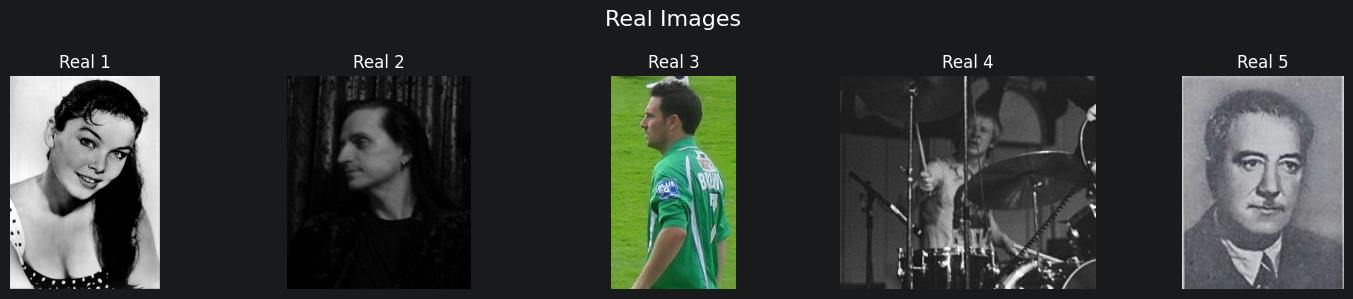

In [3]:
first_5_real = real_images[:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle("Real Images", fontsize=16)

for i, path in enumerate(first_5_real):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img_rgb)
    axes[i].set_title(f"Real {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

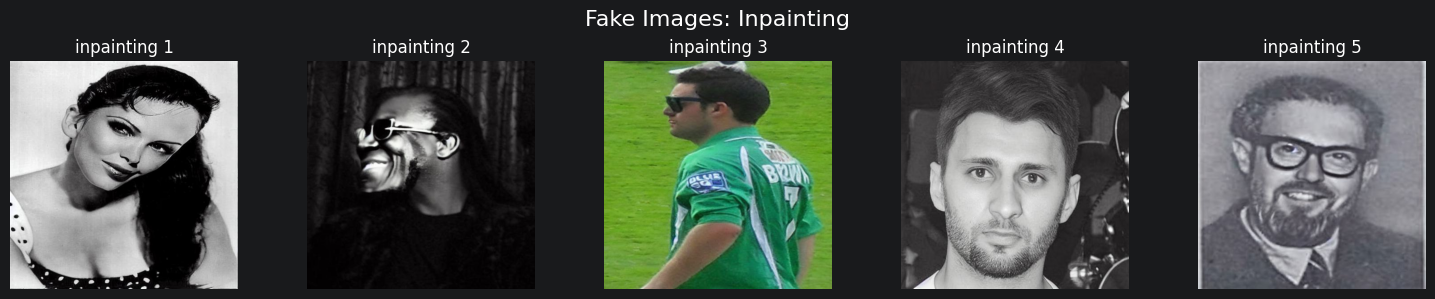

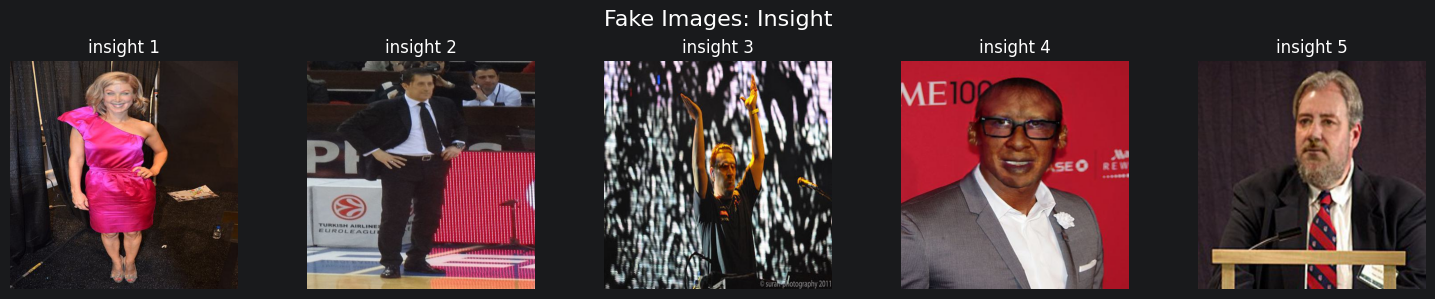

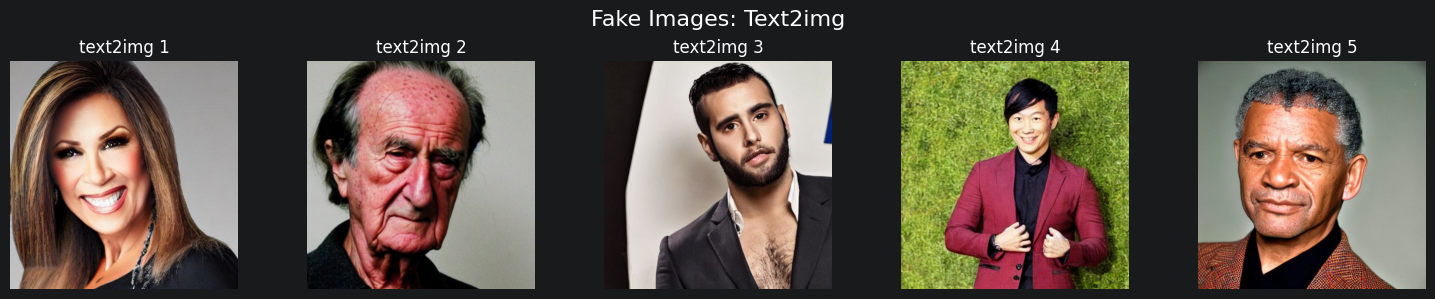

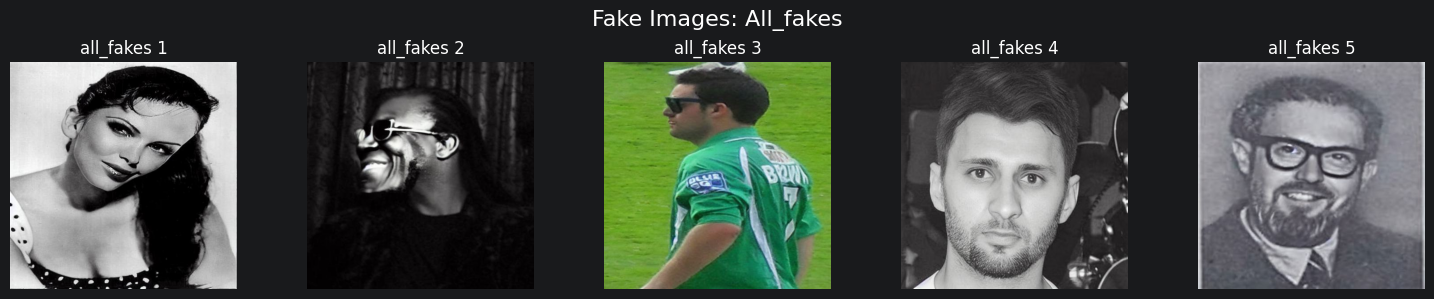

In [4]:
for folder_name, paths in fake_images_dict.items():

    first_5_category = paths[:5]

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(f"Fake Images: {folder_name.capitalize()}", fontsize=16)

    for i, path in enumerate(first_5_category):
        img = cv2.imread(path)

        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img_rgb)

        axes[i].set_title(f"{folder_name} {i+1}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

## Preprocessing

In [5]:
class DeepFakeDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, 'filepath']
        label = self.dataframe.loc[idx, 'label']

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = torch.tensor([label], dtype=torch.float32)

        return image, label

In [6]:
def create_preprocessing_pipeline(real_list, fake_dict, batch_size=32, img_size=(224, 224),
                                   fake_index=3, model_type=None, use_augmentation=False):
    """
    Takes a list of real images and a fake_dict, splits the data,
    and returns PyTorch DataLoaders and the split DataFrames.

    Additional Feature: use_augmentation (bool) - enables training-only data augmentation.
    """

    print("Building DataFrames...")
    df_real = pd.DataFrame({'filepath': real_list, 'label': 0, 'source': 'wiki'})

    folder_names = list(fake_dict.keys())

    if not (0 <= fake_index <= len(folder_names) - 1):
        raise ValueError(f"fake_index must be between 0 and {len(folder_names) - 1}")

    selected = folder_names[fake_index]
    df_fake = pd.DataFrame({'filepath': fake_dict[selected], 'label': 1, 'source': selected})
    print(f"Using fake category: {selected} ({len(df_fake)} samples)")

    # Combine into full dataset
    df_full = pd.concat([df_real, df_fake], ignore_index=True)

    print("Splitting Data (70% Train, 15% Val, 15% Test)...")
    train_df, temp_df = train_test_split(
        df_full, test_size=0.30, random_state=42, stratify=df_full['label']
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, random_state=42, stratify=temp_df['label']
    )

    # --- SETTING UP TRANSFORMS ---
    print("Setting up Transforms and DataLoaders...")

    # Base Transforms (Always applied)
    base_transforms = [transforms.Resize(img_size)]

    # Final Transforms (Always applied at the end)
    final_transforms = [transforms.ToTensor()]

    if model_type == 'imagenet':
        print(" -> Applying ImageNet Normalization.")
        final_transforms.append(transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]))
    elif model_type == 'xception':
        print(" -> Applying Xception [-1, 1] Normalization.")
        final_transforms.append(transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]))
    else:
        print(" -> No additional normalization applied.")

    # Augmentation logic (ONLY for Training)
    aug_list = []
    if use_augmentation:
        print(" -> Training Augmentation: ENABLED (Flip, Rotation, ColorJitter)")
        aug_list = [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
        ]
    else:
        print(" -> Training Augmentation: DISABLED")

    # Construct two separate Compose objects
    train_transform = transforms.Compose(base_transforms + aug_list + final_transforms)
    val_test_transform = transforms.Compose(base_transforms + final_transforms)

    # Apply specific transforms to each dataset
    train_dataset = DeepFakeDataset(train_df, transform=train_transform)
    val_dataset   = DeepFakeDataset(val_df,   transform=val_test_transform)
    test_dataset  = DeepFakeDataset(test_df,  transform=val_test_transform)

    # --- DATALOADERS ---
    use_pin_memory = torch.cuda.is_available()

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=4, pin_memory=use_pin_memory,
                              persistent_workers=True)

    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                              num_workers=4, pin_memory=use_pin_memory,
                              persistent_workers=True)

    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                              num_workers=4, pin_memory=use_pin_memory,
                              persistent_workers=True)

    print("Pipeline Complete!\n")
    return train_loader, val_loader, test_loader, train_df, val_df, test_df

## Model Training Helpers

In [7]:
def compute_binary_metrics(all_labels, all_preds, all_probs):
    accuracy = (np.array(all_preds) == np.array(all_labels)).mean() * 100
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    try:
        roc_auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        roc_auc = float("nan")

    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds, labels=[0, 1]).ravel()

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn
    }

In [8]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            if labels.dim() == 1:
                labels = labels.unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()

            all_labels.extend(labels.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    epoch_loss = running_loss / len(data_loader)
    metrics = compute_binary_metrics(all_labels, all_preds, all_probs)
    metrics["loss"] = epoch_loss

    return metrics


In [9]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, experiment_name, model_name, base_log_dir="experiment_logs", epochs=15, scheduler=None, patience=5, min_delta=1e-4):
    print(f"Starting experiment: {experiment_name}")

    history = {
        "train_loss": [], "train_accuracy": [], "train_precision": [],
        "train_recall": [], "train_f1": [], "train_roc_auc": [],
        "train_tp": [], "train_tn": [], "train_fp": [], "train_fn": [],
        "val_loss": [], "val_accuracy": [], "val_precision": [],
        "val_recall": [], "val_f1": [], "val_roc_auc": [],
        "val_tp": [], "val_tn": [], "val_fp": [], "val_fn": []
    }

    model_dir = os.path.join(base_log_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)

    log_filepath = os.path.join(model_dir, "logs.txt")
    model_filepath = os.path.join(model_dir, f"model_{experiment_name}.pth")

    # Tracking variables for Early Stopping & Checkpointing
    best_val_loss = float('inf')
    epochs_no_improve = 0

    with open(log_filepath, "a") as f:
        f.write(f"Experiment: {experiment_name}\n")
        f.write("-" * 40 + "\n")
        f.flush()

        for epoch in range(epochs):
            model.train()
            running_loss = 0.0
            all_labels, all_preds, all_probs = [], [], []

            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                if labels.dim() == 1:
                    labels = labels.unsqueeze(1)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                probs = torch.sigmoid(outputs)
                preds = (probs >= 0.5).float()

                all_labels.extend(labels.detach().cpu().numpy().flatten())
                all_preds.extend(preds.detach().cpu().numpy().flatten())
                all_probs.extend(probs.detach().cpu().numpy().flatten())

            train_loss = running_loss / len(train_loader)
            train_metrics = compute_binary_metrics(all_labels, all_preds, all_probs)
            train_metrics["loss"] = train_loss

            val_metrics = evaluate_model(model, val_loader, criterion, device)

            history["train_loss"].append(train_metrics["loss"])
            history["train_accuracy"].append(train_metrics["accuracy"])
            history["train_precision"].append(train_metrics["precision"])
            history["train_recall"].append(train_metrics["recall"])
            history["train_f1"].append(train_metrics["f1"])
            history["train_roc_auc"].append(train_metrics["roc_auc"])
            history["train_tp"].append(train_metrics["tp"])
            history["train_tn"].append(train_metrics["tn"])
            history["train_fp"].append(train_metrics["fp"])
            history["train_fn"].append(train_metrics["fn"])

            history["val_loss"].append(val_metrics["loss"])
            history["val_accuracy"].append(val_metrics["accuracy"])
            history["val_precision"].append(val_metrics["precision"])
            history["val_recall"].append(val_metrics["recall"])
            history["val_f1"].append(val_metrics["f1"])
            history["val_roc_auc"].append(val_metrics["roc_auc"])
            history["val_tp"].append(val_metrics["tp"])
            history["val_tn"].append(val_metrics["tn"])
            history["val_fp"].append(val_metrics["fp"])
            history["val_fn"].append(val_metrics["fn"])

            log_entry = (
                f"Epoch {epoch+1}:\n"
                f"  TRAIN -> Loss {train_metrics['loss']:.4f}, Accuracy {train_metrics['accuracy']:.2f}%, Precision {train_metrics['precision']:.4f}, Recall {train_metrics['recall']:.4f}, F1 {train_metrics['f1']:.4f}, ROC-AUC {train_metrics['roc_auc']:.4f}, TP {train_metrics['tp']}, TN {train_metrics['tn']}, FP {train_metrics['fp']}, FN {train_metrics['fn']}\n"
                f"  VAL   -> Loss {val_metrics['loss']:.4f}, Accuracy {val_metrics['accuracy']:.2f}%, Precision {val_metrics['precision']:.4f}, Recall {val_metrics['recall']:.4f}, F1 {val_metrics['f1']:.4f}, ROC-AUC {val_metrics['roc_auc']:.4f}, TP {val_metrics['tp']}, TN {val_metrics['tn']}, FP {val_metrics['fp']}, FN {val_metrics['fn']}\n"
            )

            f.write(log_entry)
            f.flush()

            # --- Checkpointing and Early Stopping Logic ---
            current_val_loss = val_metrics["loss"]
            console_msg = ""

            if current_val_loss < (best_val_loss - min_delta):
                best_val_loss = current_val_loss
                epochs_no_improve = 0
                torch.save(model.state_dict(), model_filepath)
                console_msg = f"[*] New best model saved! (Val Loss: {best_val_loss:.4f})"
            else:
                epochs_no_improve += 1
                console_msg = f"[-] No improvement for {epochs_no_improve} epoch(s)."

            if scheduler is not None:
                scheduler.step(current_val_loss)

            current_lr = optimizer.param_groups[0]["lr"]
            print(f"Finished {log_entry.strip()} | LR: {current_lr:.6f} | {console_msg}")

            # Early Stopping Check
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered! Validation loss hasn't improved by at least {min_delta} in {patience} epochs.")
                break

    # Restore best weights before returning
    print(f"\nLoading best model weights from: {model_filepath}")
    model.load_state_dict(torch.load(model_filepath, map_location=device))
    print(f"Logs saved to: {log_filepath}")

    return model, history

In [10]:
def run_experiment_suite(model_factory, model_name, img_size, model_type, lr,
                         fake_images_dict, real_images, device, use_augmentation=False,
                         base_log_dir="experiment_logs", epochs=15,
                         experiments_to_run=[0, 1, 2, 3]):
    """
    Runs the specified dataset experiments for a given model.
    Includes support for toggling Data Augmentation and selecting specific experiments.
    """

    all_models = {}
    all_histories = {}
    all_test_metrics = {}

    subfolder = "augmentation" if use_augmentation else "no_augmentation"
    effective_log_dir = os.path.join(base_log_dir, subfolder)

    model_dir = os.path.join(effective_log_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)

    log_file = os.path.join(model_dir, "logs.txt")

    folder_names = list(fake_images_dict.keys())

    for fake_idx in experiments_to_run:
        experiment_name = "all_fakes" if fake_idx == 3 else folder_names[fake_idx]

        # Check skip logic
        if os.path.exists(log_file):
            with open(log_file, "r") as f:
                if f"Experiment: {experiment_name}" in f.read():
                    print(f"Skipping {experiment_name.upper()}: Found in {subfolder}/{model_name}")
                    continue

        print(f"\n{'='*60}")
        print(f"STARTING EXPERIMENT: {experiment_name.upper()}")
        print(f"Model: {model_name} | Mode: {subfolder.upper()}")
        print(f"{'='*60}")

        train_loader, val_loader, test_loader, train_df, _, _ = create_preprocessing_pipeline(
            real_list=real_images,
            fake_dict=fake_images_dict,
            batch_size=32,
            img_size=img_size,
            fake_index=fake_idx,
            model_type=model_type,
            use_augmentation=use_augmentation
        )

        # pos_weight logic
        num_real = len(train_df[train_df['label'] == 0])
        num_fake = len(train_df[train_df['label'] == 1])
        pos_weight = torch.tensor([num_real / num_fake], dtype=torch.float32).to(device)

        # Model Setup
        model = model_factory().to(device)
        if device.type == 'cuda' and int(torch.__version__.split('.')[0]) >= 2:
            model = torch.compile(model)

        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

        # Train
        trained_model, train_history = train_model(
            model=model, train_loader=train_loader, val_loader=val_loader,
            criterion=criterion, optimizer=optimizer, device=device,
            experiment_name=experiment_name, model_name=model_name,
            base_log_dir=effective_log_dir,
            epochs=epochs, scheduler=scheduler
        )

        # Evaluate
        test_metrics = evaluate_model(trained_model, test_loader, criterion, device)

        # Log Test Metrics
        with open(log_file, "a", encoding="utf-8") as f:
            f.write(
                f"  TEST  -> Loss {test_metrics['loss']:.4f}, Accuracy {test_metrics['accuracy']:.2f}%, "
                f"Precision {test_metrics['precision']:.4f}, Recall {test_metrics['recall']:.4f}, "
                f"F1 {test_metrics['f1']:.4f}, ROC-AUC {test_metrics['roc_auc']:.4f}, "
                f"TP {test_metrics['tp']}, TN {test_metrics['tn']}, FP {test_metrics['fp']}, FN {test_metrics['fn']}\n\n"
            )

        all_models[experiment_name] = trained_model
        all_histories[experiment_name] = train_history
        all_test_metrics[experiment_name] = test_metrics

    print(f"\n SUITE COMPLETED: {model_name} in {subfolder.upper()}")
    return all_models, all_histories, all_test_metrics

## Results Visualization Helpers

In [11]:
def parse_experiment_logs(log_filepath):
    parsed_histories = {}
    parsed_test_metrics = {}
    current_experiment = None

    if not os.path.exists(log_filepath):
        print(f"Log file not found at {log_filepath}")
        return parsed_histories, parsed_test_metrics

    METRIC_FIELDS = ["train", "val"]
    HISTORY_KEYS  = ["loss", "accuracy", "precision", "recall", "f1", "roc_auc"]

    with open(log_filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            if line.startswith("Experiment:"):
                current_experiment = line.split("Experiment:")[1].strip()
                parsed_histories[current_experiment] = {
                    f"{split}_{metric}": []
                    for split in METRIC_FIELDS
                    for metric in HISTORY_KEYS
                }

            elif current_experiment:
                if   "TRAIN ->" in line: prefix = "train"
                elif "VAL   ->" in line: prefix = "val"
                elif "TEST  ->" in line: prefix = "test"
                else: continue

                patterns = {
                    "loss":      r"Loss ([\d\.]+)",
                    "accuracy":  r"Accuracy ([\d\.]+)",
                    "precision": r"Precision ([\d\.]+)",
                    "recall":    r"Recall ([\d\.]+)",
                    "f1":        r"F1 ([\d\.]+)",
                    "roc_auc":   r"ROC-AUC ([\d\.]+)",
                }
                extracted = {}
                for metric, pattern in patterns.items():
                    match = re.search(pattern, line)
                    if match:
                        value = float(match.group(1))
                        # Normalize accuracy from percentage to 0-1
                        extracted[metric] = value / 100.0 if metric == "accuracy" else value

                if prefix in ("train", "val"):
                    for metric, value in extracted.items():
                        key = f"{prefix}_{metric}"
                        if key in parsed_histories[current_experiment]:
                            parsed_histories[current_experiment][key].append(value)
                elif prefix == "test":
                    parsed_test_metrics[current_experiment] = extracted

    return parsed_histories, parsed_test_metrics

In [12]:
def plot_experiment_results(histories_dict=None, test_metrics_dict=None, log_filepath=None):
    if log_filepath:
        print(f"Fetching plot data directly from logs: {log_filepath}")
        histories_dict, test_metrics_dict = parse_experiment_logs(log_filepath)
    if not histories_dict:
        print("No history data available to plot.")
        return

    experiments = list(histories_dict.keys())
    palette     = plt.cm.tab10.colors
    exp_colors  = {name: palette[i % len(palette)] for i, name in enumerate(experiments)}

    METRICS = [
        ("loss",      "Loss",      "Loss"),
        ("accuracy",  "Accuracy",  "Accuracy (0-1)"),
        ("precision", "Precision", "Precision"),
        ("recall",    "Recall",    "Recall"),
        ("f1",        "F1 Score",  "F1"),
        ("roc_auc",   "ROC-AUC",   "ROC-AUC"),
    ]

    # Validate and report missing/empty metrics before plotting
    print("=" * 60)
    print("DATA VALIDATION REPORT")
    print("=" * 60)
    has_warnings = False
    for exp_name in experiments:
        history = histories_dict[exp_name]
        for split in ("train", "val"):
            for key, title, _ in METRICS:
                values = history.get(f"{split}_{key}", [])
                if not values:
                    print(f"  [MISSING]  {exp_name} | {split.upper():5s} | {title}")
                    has_warnings = True
                elif any(v is None or (isinstance(v, float) and (v != v)) for v in values):
                    print(f"  [NaN/None] {exp_name} | {split.upper():5s} | {title}")
                    has_warnings = True
                elif len(values) != len(history.get("train_loss", [])):
                    print(f"  [LENGTH MISMATCH] {exp_name} | {split.upper():5s} | {title} "
                          f" got {len(values)} entries vs {len(history.get('train_loss', []))} epochs")
                    has_warnings = True
        if test_metrics_dict:
            test = test_metrics_dict.get(exp_name, {})
            for key, title, _ in METRICS:
                if key == "loss":
                    continue
                if key not in test:
                    print(f"  [MISSING]  {exp_name} | TEST  | {title}")
                    has_warnings = True
    if not has_warnings:
        print("  All metrics present and valid for all experiments.")
    print("=" * 60 + "\n")

    # Build figure: 6 rows (metrics) 3 cols (Train | Val | Test)
    N_ROWS = len(METRICS)
    fig, axes = plt.subplots(
        N_ROWS, 3,
        figsize=(20, N_ROWS * 4),
        constrained_layout=True
    )
    fig.suptitle("Experiment Results\n\n", fontsize=18, fontweight="bold")

    # Column headers
    for col, label in enumerate(["Train", "Validation", "Test"]):
        axes[0, col].set_title(label, fontsize=13, fontweight="bold", pad=14)

    for row_idx, (key, title, ylabel) in enumerate(METRICS):
        ax_train = axes[row_idx, 0]
        ax_val   = axes[row_idx, 1]
        ax_test  = axes[row_idx, 2]

        # Train and Val line plots
        for split, ax in (("train", ax_train), ("val", ax_val)):
            for exp_name in experiments:
                values = histories_dict[exp_name].get(f"{split}_{key}", [])
                if not values:
                    continue
                epochs = range(1, len(values) + 1)
                ax.plot(epochs, values,
                        label=exp_name,
                        color=exp_colors[exp_name],
                        linewidth=1.8, marker='o', markersize=3)
            ax.set_ylabel(ylabel, fontsize=8)
            ax.set_xlabel("Epoch", fontsize=8)
            ax.tick_params(labelsize=7)
            ax.grid(True, linestyle=':', alpha=0.6)
            # Row label on the leftmost axis only
            if split == "train":
                ax.set_ylabel(f"{title}\n\n{ylabel}", fontsize=8)

        # Test bar chart
        if key != "loss":   # test loss is usually not reported, keep slot clean
            values = [
                (test_metrics_dict or {}).get(exp, {}).get(key, 0)
                for exp in experiments
            ]
            bars = ax_test.bar(
                range(len(experiments)), values,
                color=[exp_colors[e] for e in experiments],
                edgecolor="white", linewidth=0.8
            )
            for bar, v in zip(bars, values):
                if v > 0:
                    ax_test.annotate(
                        f"{v:.3f}",
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                        xytext=(0, 4), textcoords="offset points",
                        ha="center", va="bottom", fontsize=8, fontweight="bold"
                    )
            ax_test.set_xticks(list(range(len(experiments))))
            ax_test.set_xticklabels(experiments, rotation=25, ha="right", fontsize=7)
            ax_test.set_ylabel(ylabel, fontsize=8)
            ax_test.tick_params(axis='y', labelsize=7)
            ax_test.set_ylim(0, min(1.15, max(values, default=1) * 1.2) if any(values) else 1)
            ax_test.grid(True, axis='y', linestyle=':', alpha=0.6)
            if not any(values):
                ax_test.text(0.5, 0.5, "No Test Data", ha="center", va="center",
                             transform=ax_test.transAxes, fontsize=8, color="gray")
        else:
            ax_test.axis("off")
            ax_test.text(0.5, 0.5, "Test Loss\nNot Reported", ha="center", va="center",
                         transform=ax_test.transAxes, fontsize=8, color="gray")

    handles, labels = axes[0, 0].get_legend_handles_labels()

    axes[0, 1].legend(
        handles, labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.25),
        ncol=len(experiments),
        fontsize=10,
        frameon=True,
        title="Experiments",
        title_fontsize=10
    )

    plt.show()

In [13]:
indices = random.sample(range(min(len(v) for v in fake_images_dict.values())), 10)

samples = [
    {
        "inpainting": fake_images_dict["inpainting"][idx],
        "insight":    fake_images_dict["insight"][idx],
        "text2img":   fake_images_dict["text2img"][idx],
        "all_fakes":  fake_images_dict["all_fakes"][idx],
    }
    for idx in indices
]

## Model Loader

In [14]:
def load_models(model_factory, model_name, experiments, device, in_memory=None, use_augmentation=False):
    """
    For each experiment, use the in-memory model if available, otherwise
    load the saved checkpoint from disk.
    """
    models = {}

    subfolder = "augmentation" if use_augmentation else "no_augmentation"

    for exp_name in experiments:
        if in_memory and exp_name in in_memory:
            print(f"[{exp_name}] using in-memory model from {subfolder}")
            model = in_memory[exp_name]
        else:
            ckpt_path = os.path.join("experiment_logs", subfolder, model_name, f"model_{exp_name}.pth")

            if not os.path.exists(ckpt_path):
                raise FileNotFoundError(
                    f"[{exp_name}] No checkpoint found in {subfolder} at:\n"
                    f"  {ckpt_path}\n"
                    f"Make sure you set use_augmentation={use_augmentation} correctly."
                )

            print(f"[{exp_name}] loading checkpoint from {ckpt_path}")
            model = model_factory()
            model.load_state_dict(torch.load(ckpt_path, map_location=device))

        model.to(device).eval()
        models[exp_name] = model

    return models

## Device Configuration

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Device set to: {device}")

Device set to: cpu


## Model Training Without Augmentation

In [16]:
USE_AUG = False
SUBFOLDER = "no_augmentation"
print(f"--- MODE: {SUBFOLDER.upper()} ---")

--- MODE: NO_AUGMENTATION ---


### NN

#### NN_1

In [17]:
img_size = (64, 64)

# --- NN_1 ---
all_models, all_histories, all_test_metrics = run_experiment_suite(
    model_factory=lambda: DeepFakeNN_1(img_size),
    model_name="NN_1",
    img_size=img_size,
    model_type=None,
    lr=0.001,
    fake_images_dict=fake_images_dict,
    real_images=real_images,
    device=device,
    use_augmentation=USE_AUG,
    epochs=15
)

Skipping INPAINTING: Found in no_augmentation/NN_1
Skipping INSIGHT: Found in no_augmentation/NN_1
Skipping TEXT2IMG: Found in no_augmentation/NN_1
Skipping ALL_FAKES: Found in no_augmentation/NN_1

 SUITE COMPLETED: NN_1 in NO_AUGMENTATION


Fetching plot data directly from logs: experiment_logs/no_augmentation/NN_1/logs.txt
DATA VALIDATION REPORT
  All metrics present and valid for all experiments.



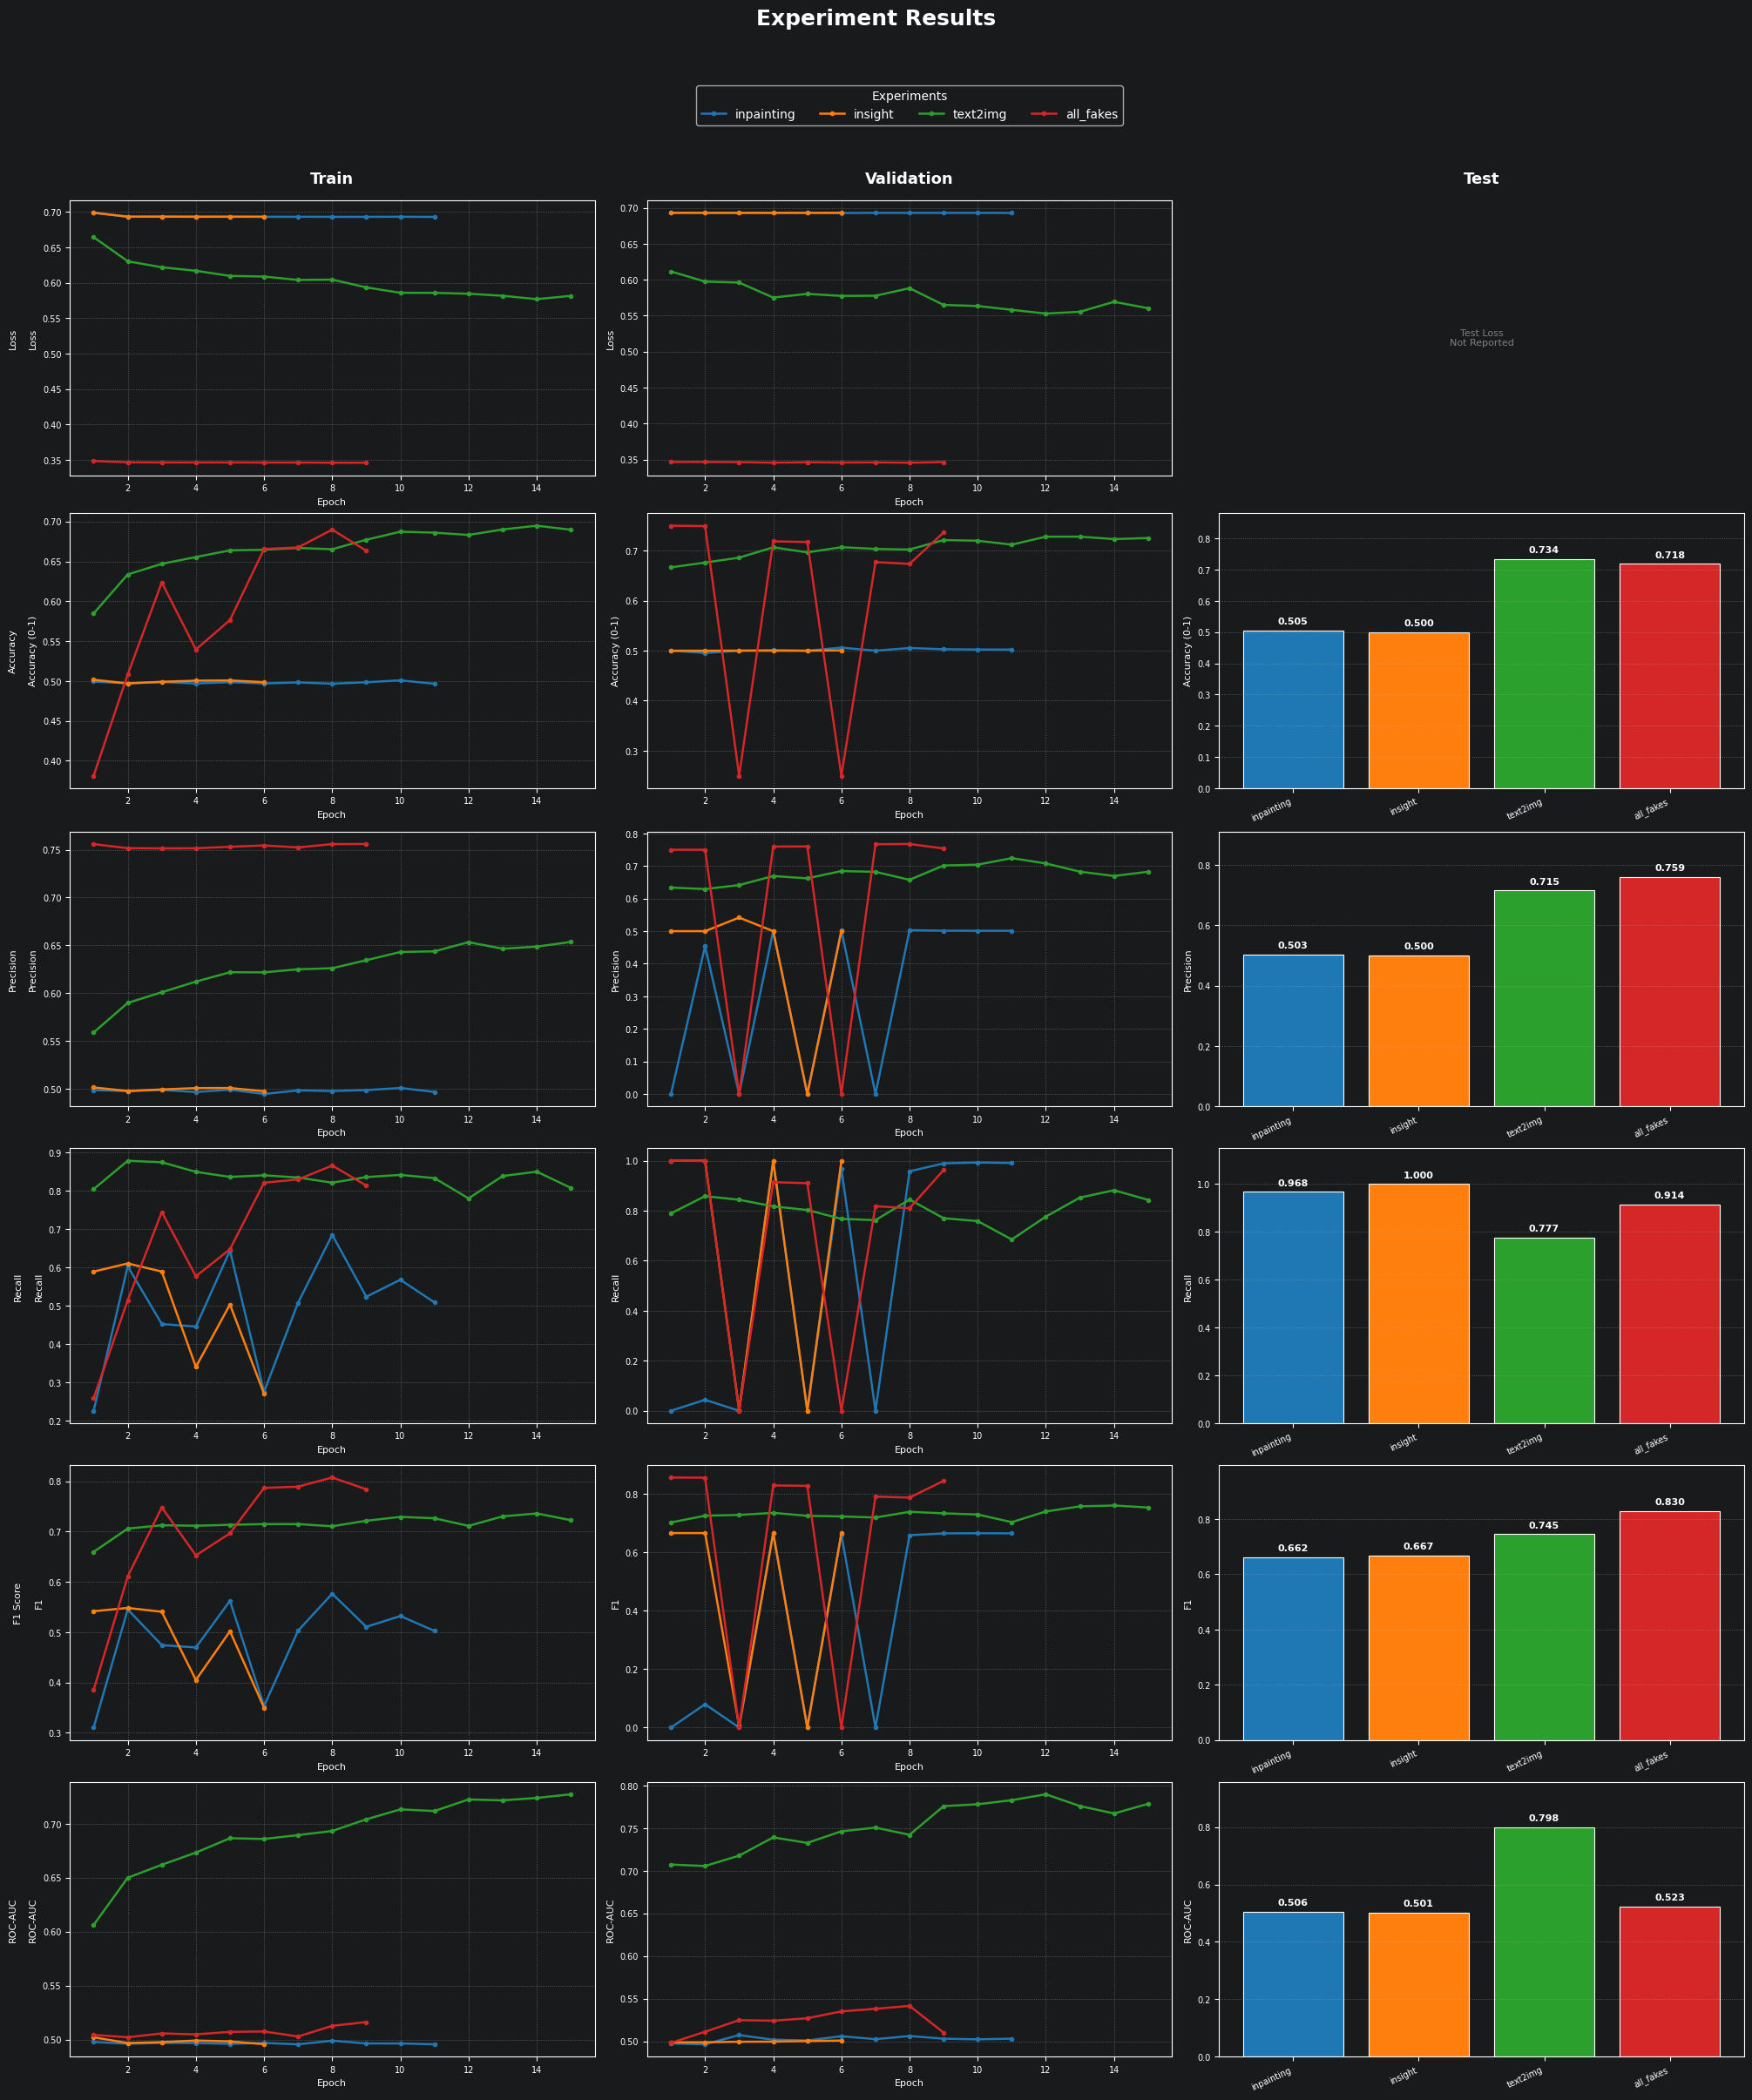

In [18]:
log_file_path = os.path.join("experiment_logs", SUBFOLDER, "NN_1", "logs.txt")

if ('all_histories' in locals() and all_histories) and ('all_test_metrics' in locals() and all_test_metrics):
    plot_experiment_results(all_histories, all_test_metrics, log_filepath=None)
else:
    plot_experiment_results(None, None, log_filepath=log_file_path)

### CNN


#### ResNet

#### Fine Tuning Last Layer

In [19]:
img_size = (224, 224)

# --- ResNet34 Frozen ---
all_resnet_frozen_models, all_resnet_frozen_histories, all_resnet_frozen_test_metrics = run_experiment_suite(
    model_factory=lambda: DeepFakeResNet34(freeze_features=True),
    model_name="ResNet34_frozen",
    img_size=img_size,
    model_type="imagenet",
    lr=0.001,
    fake_images_dict=fake_images_dict,
    real_images=real_images,
    device=device,
    use_augmentation=USE_AUG,
    epochs=15
)

Skipping INPAINTING: Found in no_augmentation/ResNet34_frozen
Skipping INSIGHT: Found in no_augmentation/ResNet34_frozen
Skipping TEXT2IMG: Found in no_augmentation/ResNet34_frozen
Skipping ALL_FAKES: Found in no_augmentation/ResNet34_frozen

 SUITE COMPLETED: ResNet34_frozen in NO_AUGMENTATION


Fetching plot data directly from logs: experiment_logs/no_augmentation/ResNet34_frozen/logs.txt
DATA VALIDATION REPORT
  All metrics present and valid for all experiments.



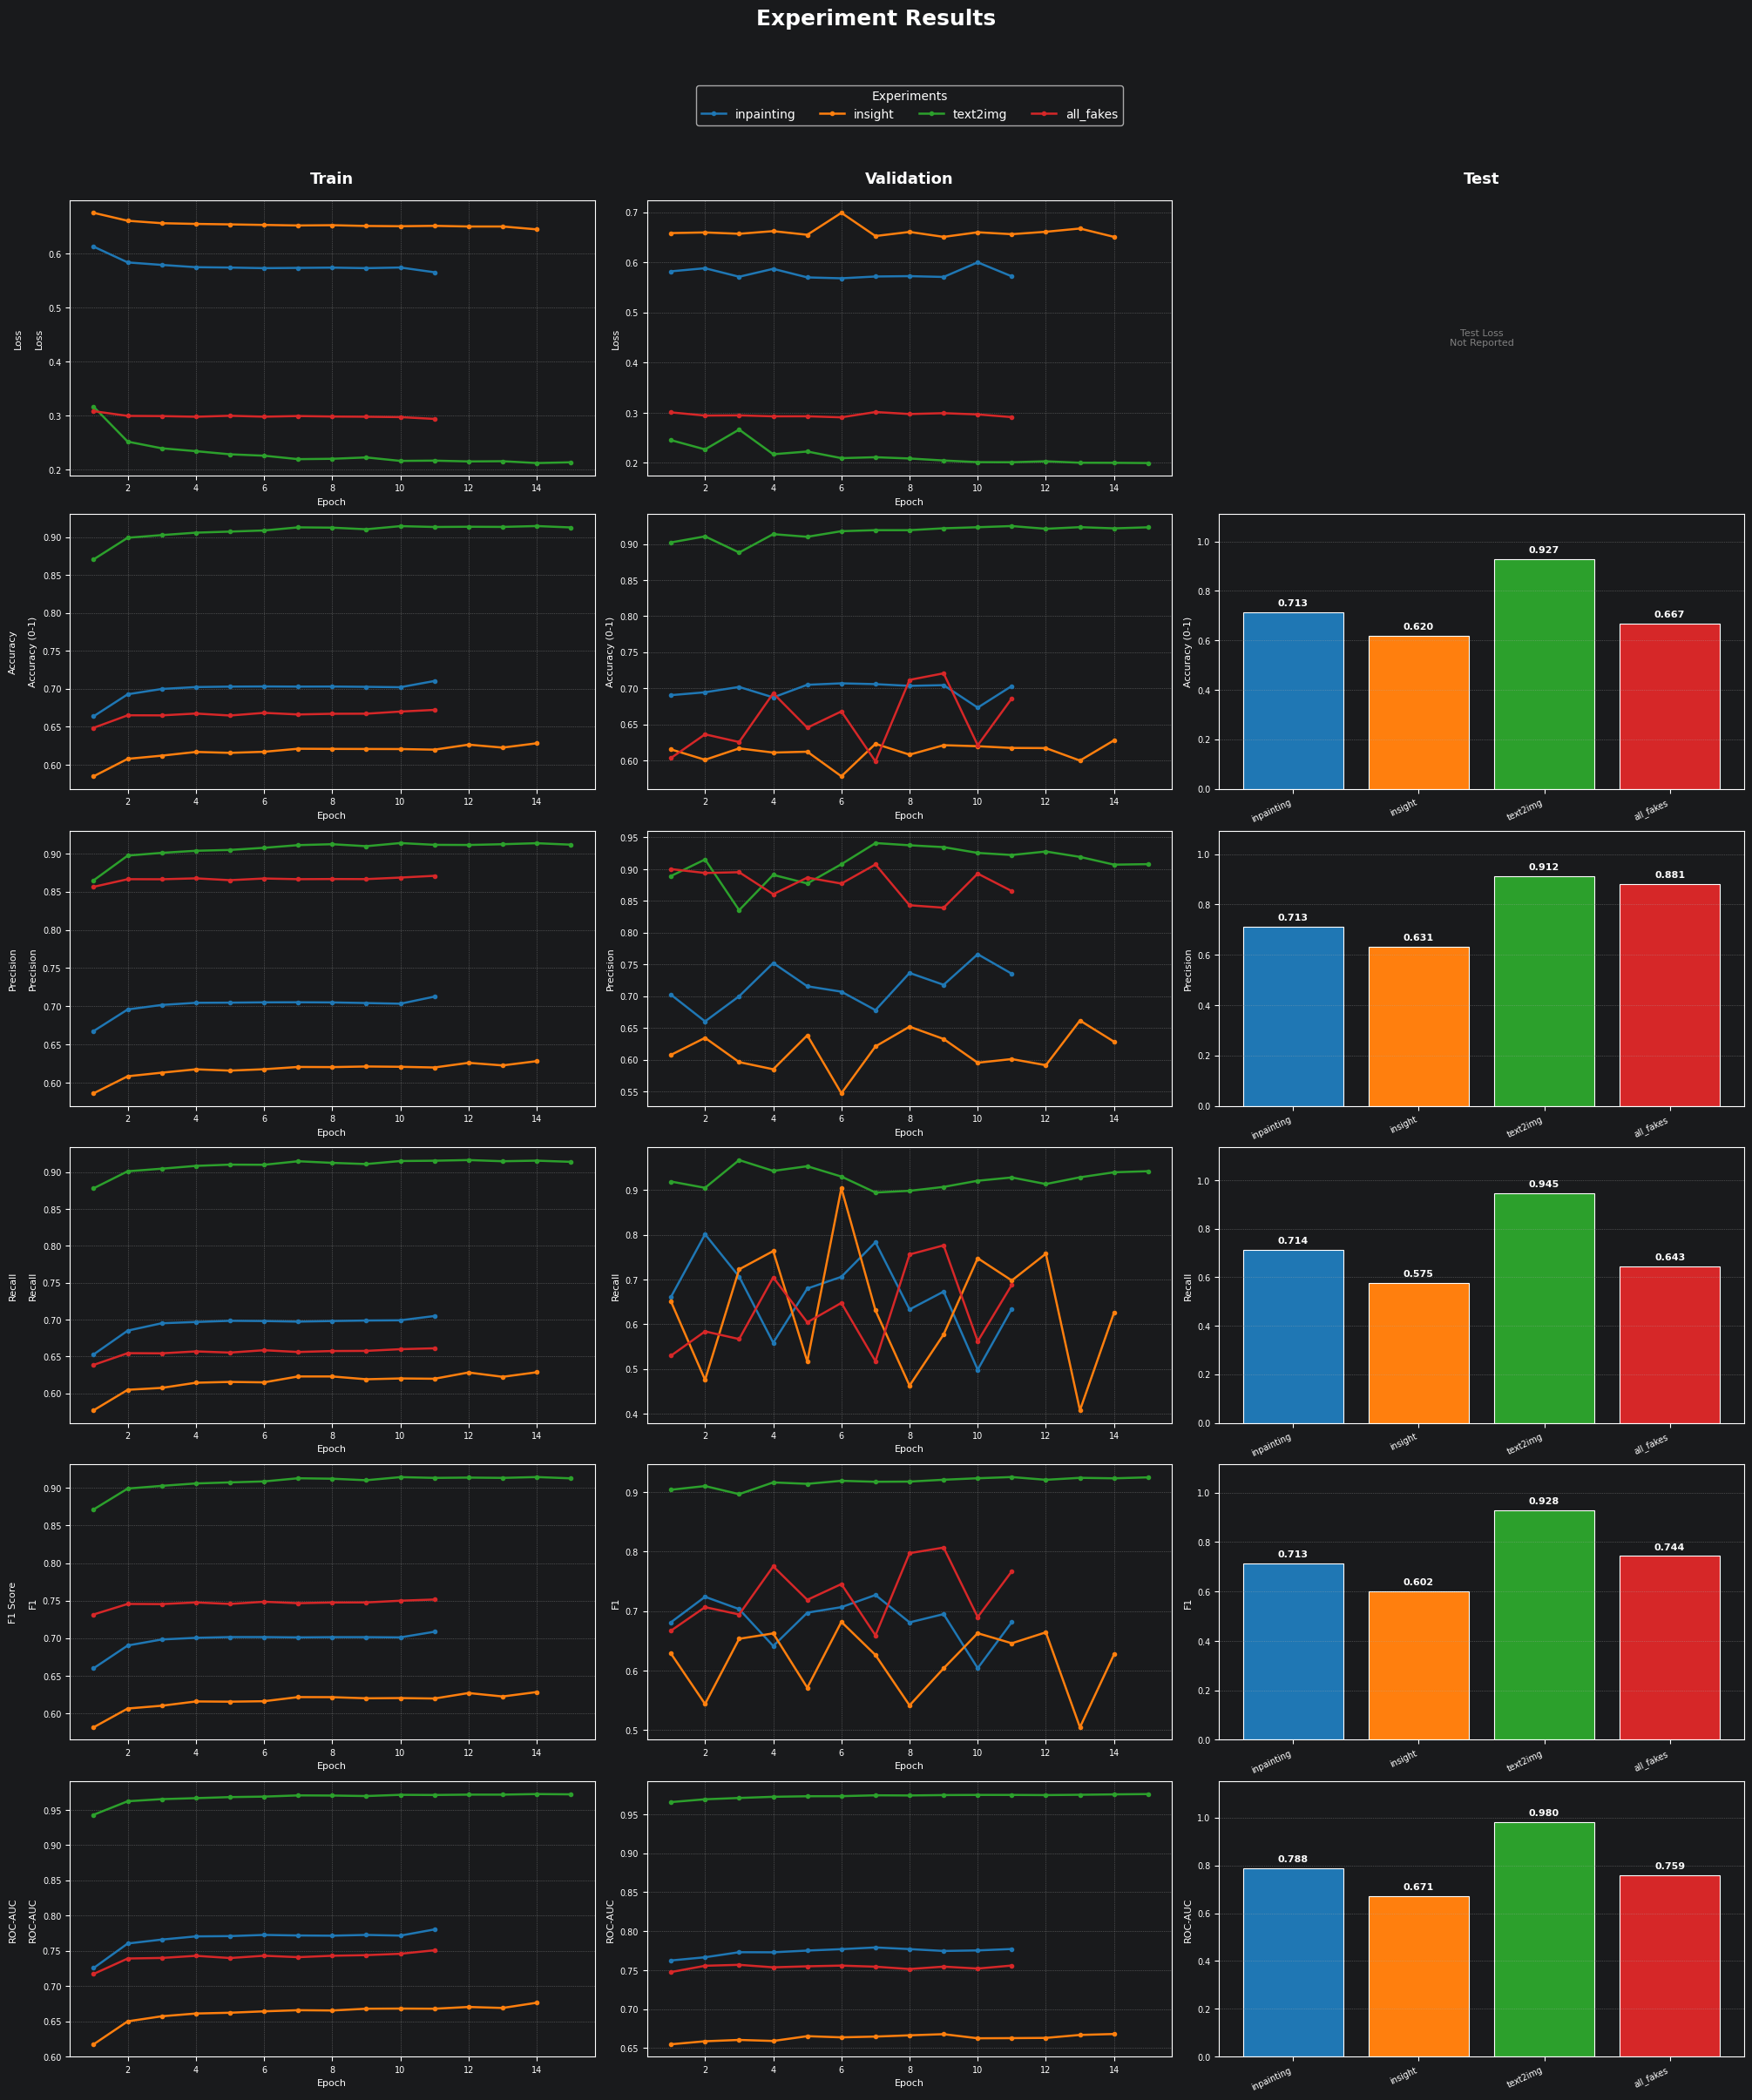

In [20]:
resnet_frozen_log = os.path.join("experiment_logs", SUBFOLDER, "ResNet34_frozen", "logs.txt")

if ('all_resnet_frozen_histories' in locals() and all_resnet_frozen_histories) and ('all_resnet_frozen_test_metrics' in locals() and all_resnet_frozen_test_metrics):
    plot_experiment_results(all_resnet_frozen_histories, all_resnet_frozen_test_metrics, log_filepath=None)
else:
    plot_experiment_results(None, None, log_filepath=resnet_frozen_log)

In [21]:
models_resnet_frozen = load_models(
    lambda: DeepFakeResNet34(freeze_features=True), "ResNet34_frozen",
    ["inpainting", "insight", "text2img", "all_fakes"],
    device, all_resnet_frozen_models, use_augmentation=USE_AUG
)

for i, images in enumerate(samples):
    visualize_gradcam_grid(models_dict=models_resnet_frozen, images=images, device=device,
                           title=f"ResNet34 Frozen ({SUBFOLDER}) sample {i+1}")

[inpainting] loading checkpoint from experiment_logs/no_augmentation/ResNet34_frozen/model_inpainting.pth


RuntimeError: Error(s) in loading state_dict for DeepFakeResNet34:
	Missing key(s) in state_dict: "resnet.conv1.weight", "resnet.bn1.weight", "resnet.bn1.bias", "resnet.bn1.running_mean", "resnet.bn1.running_var", "resnet.layer1.0.conv1.weight", "resnet.layer1.0.bn1.weight", "resnet.layer1.0.bn1.bias", "resnet.layer1.0.bn1.running_mean", "resnet.layer1.0.bn1.running_var", "resnet.layer1.0.conv2.weight", "resnet.layer1.0.bn2.weight", "resnet.layer1.0.bn2.bias", "resnet.layer1.0.bn2.running_mean", "resnet.layer1.0.bn2.running_var", "resnet.layer1.1.conv1.weight", "resnet.layer1.1.bn1.weight", "resnet.layer1.1.bn1.bias", "resnet.layer1.1.bn1.running_mean", "resnet.layer1.1.bn1.running_var", "resnet.layer1.1.conv2.weight", "resnet.layer1.1.bn2.weight", "resnet.layer1.1.bn2.bias", "resnet.layer1.1.bn2.running_mean", "resnet.layer1.1.bn2.running_var", "resnet.layer1.2.conv1.weight", "resnet.layer1.2.bn1.weight", "resnet.layer1.2.bn1.bias", "resnet.layer1.2.bn1.running_mean", "resnet.layer1.2

#### Fine Tuning All Layers

In [ ]:
img_size = (224, 224)

# --- ResNet34 Full ---
all_resnet_models, all_resnet_histories, all_resnet_test_metrics = run_experiment_suite(
    model_factory=lambda: DeepFakeResNet34(freeze_features=False),
    model_name="ResNet34_full",
    img_size=img_size,
    model_type="imagenet",
    lr=0.0001,
    fake_images_dict=fake_images_dict,
    real_images=real_images,
    device=device,
    use_augmentation=USE_AUG,
    epochs=15
)

In [ ]:
resnet_full_log = os.path.join("experiment_logs", SUBFOLDER, "ResNet34_full", "logs.txt")

if ('all_resnet_histories' in locals() and all_resnet_histories) and ('all_resnet_test_metrics' in locals() and all_resnet_test_metrics):
    plot_experiment_results(all_resnet_histories, all_resnet_test_metrics, log_filepath=None)
else:
    plot_experiment_results(None, None, log_filepath=resnet_full_log)

In [ ]:
models_resnet_full = load_models(
    lambda: DeepFakeResNet34(freeze_features=False), "ResNet34_full",
    ["inpainting", "insight", "text2img", "all_fakes"],
    device, all_resnet_models, use_augmentation=USE_AUG
)

for i, images in enumerate(samples):
    visualize_gradcam_grid(models_dict=models_resnet_full, images=images, device=device,
                           title=f"ResNet34 Full ({SUBFOLDER}) sample {i+1}")

#### EfficientNet

#### Fine Tuning Last Layer

In [ ]:
img_size = (224, 224)

# --- EfficientNet Frozen ---
all_efficientnet_frozen_models, all_efficientnet_frozen_histories, all_efficientnet_frozen_test_metrics = run_experiment_suite(
    model_factory=lambda: DeepFakeEfficientNet(freeze_features=True),
    model_name="EfficientNet_frozen",
    img_size=img_size,
    model_type="imagenet",
    lr=0.001,
    fake_images_dict=fake_images_dict,
    real_images=real_images,
    device=device,
    use_augmentation=USE_AUG,
    epochs=15
)

In [ ]:
effnet_frozen_log = os.path.join("experiment_logs", SUBFOLDER, "EfficientNet_frozen", "logs.txt")

if ('all_efficientnet_frozen_histories' in locals() and all_efficientnet_frozen_histories) and ('all_efficientnet_frozen_test_metrics' in locals() and all_efficientnet_frozen_test_metrics):
    plot_experiment_results(all_efficientnet_frozen_histories, all_efficientnet_frozen_test_metrics, log_filepath=None)
else:
    plot_experiment_results(None, None, log_filepath=effnet_frozen_log)

In [ ]:
models_resnet_full = load_models(
    lambda: DeepFakeResNet34(freeze_features=False), "ResNet34_full",
    ["inpainting", "insight", "text2img", "all_fakes"],
    device, all_resnet_models, use_augmentation=USE_AUG
)

for i, images in enumerate(samples):
    visualize_gradcam_grid(models_dict=models_resnet_full, images=images, device=device,
                           title=f"ResNet34 Full ({SUBFOLDER}) sample {i+1}")

#### Fine Tuning All Layers

In [ ]:
img_size = (224, 224)

# --- EfficientNet Full ---
all_efficientnet_models, all_efficientnet_histories, all_efficientnet_test_metrics = run_experiment_suite(
    model_factory=lambda: DeepFakeEfficientNet(freeze_features=False),
    model_name="EfficientNet_full",
    img_size=img_size,
    model_type="imagenet",
    lr=0.0001,
    fake_images_dict=fake_images_dict,
    real_images=real_images,
    device=device,
    use_augmentation=USE_AUG,
    epochs=15
)

In [ ]:
effnet_full_log = os.path.join("experiment_logs", SUBFOLDER, "EfficientNet_full", "logs.txt")

if ('all_efficientnet_histories' in locals() and all_efficientnet_histories) and ('all_efficientnet_test_metrics' in locals() and all_efficientnet_test_metrics):
    plot_experiment_results(all_efficientnet_histories, all_efficientnet_test_metrics, log_filepath=None)
else:
    plot_experiment_results(None, None, log_filepath=effnet_full_log)

In [ ]:
models_efficientnet_full = load_models(
    lambda: DeepFakeEfficientNet(freeze_features=False), "EfficientNet_full",
    ["inpainting", "insight", "text2img", "all_fakes"],
    device, all_efficientnet_models, use_augmentation=USE_AUG
)

for i, images in enumerate(samples):
    visualize_gradcam_grid(models_dict=models_efficientnet_full, images=images, device=device,
                           title=f"EfficientNet Full ({SUBFOLDER}) sample {i+1}")

#### Xception

#### Fine Tuning Last Layer


In [ ]:
img_size = (299, 299)

# --- Xception Frozen ---
all_xception_frozen_models, all_xception_frozen_histories, all_xception_frozen_test_metrics = run_experiment_suite(
    model_factory=lambda: DeepFakeXception(freeze_features=True),
    model_name="Xception_frozen",
    img_size=img_size,
    model_type="xception",
    lr=0.001,
    fake_images_dict=fake_images_dict,
    real_images=real_images,
    device=device,
    use_augmentation=USE_AUG,
    epochs=15
)

In [ ]:
xception_frozen_log = os.path.join("experiment_logs", SUBFOLDER, "Xception_frozen", "logs.txt")

if ('all_xception_frozen_histories' in locals() and all_xception_frozen_histories) and ('all_xception_frozen_test_metrics' in locals() and all_xception_frozen_test_metrics):
    plot_experiment_results(all_xception_frozen_histories, all_xception_frozen_test_metrics, log_filepath=None)
else:
    plot_experiment_results(None, None, log_filepath=xception_frozen_log)

In [ ]:
models_xception_frozen = load_models(
    lambda: DeepFakeXception(freeze_features=True), "Xception_frozen",
    ["inpainting", "insight", "text2img", "all_fakes"],
    device, all_xception_frozen_models, use_augmentation=USE_AUG
)

for i, images in enumerate(samples):
    visualize_gradcam_grid(models_dict=models_xception_frozen, images=images, device=device,
                           title=f"Xception Frozen ({SUBFOLDER}) sample {i + 1}")

#### Fine Tuning All Layers

In [ ]:
img_size = (299, 299)

# --- Xception Full ---
all_xception_models, all_xception_histories, all_xception_test_metrics = run_experiment_suite(
    model_factory=lambda: DeepFakeXception(freeze_features=False),
    model_name="Xception_full",
    img_size=img_size,
    model_type="xception",
    lr=0.0001,
    fake_images_dict=fake_images_dict,
    real_images=real_images,
    device=device,
    use_augmentation=USE_AUG,
    epochs=15
)

In [ ]:
xception_full_log = os.path.join("experiment_logs", SUBFOLDER, "Xception_full", "logs.txt")

if ('all_xception_histories' in locals() and all_xception_histories) and ('all_xception_test_metrics' in locals() and all_xception_test_metrics):
    plot_experiment_results(all_xception_histories, all_xception_test_metrics, log_filepath=None)
else:
    plot_experiment_results(None, None, log_filepath=xception_full_log)

In [ ]:
models_xception_full = load_models(
    lambda: DeepFakeXception(freeze_features=False), "Xception_full",
    ["inpainting", "insight", "text2img", "all_fakes"],
    device, all_xception_models, use_augmentation=USE_AUG
)

for i, images in enumerate(samples):
    visualize_gradcam_grid(models_dict=models_xception_full, images=images, device=device,
                           title=f"Xception Full ({SUBFOLDER}) sample {i+1}")

### ViT

#### ViT_B_16

#### Fine Tuning Last Layer

In [ ]:
img_size = (224, 224)

# --- ViT_B_16 Frozen ---
all_vit_frozen_models, all_vit_frozen_histories, all_vit_frozen_test_metrics = run_experiment_suite(
    model_factory=lambda: DeepFakeViT(freeze_features=True),
    model_name="ViT_B_16_frozen",
    img_size=img_size,
    model_type="imagenet",
    lr=0.001,
    fake_images_dict=fake_images_dict,
    real_images=real_images,
    device=device,
    use_augmentation=USE_AUG,
    epochs=15
)

In [ ]:
vit_frozen_log = os.path.join("experiment_logs", SUBFOLDER, "ViT_B_16_frozen", "logs.txt")

if ('all_vit_frozen_histories' in locals() and all_vit_frozen_histories) and ('all_vit_frozen_test_metrics' in locals() and all_vit_frozen_test_metrics):
    plot_experiment_results(all_vit_frozen_histories, all_vit_frozen_test_metrics, log_filepath=None)
else:
    plot_experiment_results(None, None, log_filepath=vit_frozen_log)

In [ ]:
models_vit_frozen = load_models(
    lambda: DeepFakeViT(freeze_features=True), "ViT_B_16_frozen",
    ["inpainting", "insight", "text2img", "all_fakes"],
    device, all_vit_frozen_models, use_augmentation=USE_AUG
)

for i, images in enumerate(samples):
    visualize_gradcam_grid(models_dict=models_vit_frozen, images=images, device=device,
                           title=f"ViT Frozen ({SUBFOLDER}) sample {i + 1}")

#### Fine Tuning All Layers

In [ ]:
img_size = (224, 224)

# --- ViT_B_16 Full ---
all_vit_full_models, all_vit_full_histories, all_vit_full_test_metrics = run_experiment_suite(
    model_factory=lambda: DeepFakeViT(freeze_features=False),
    model_name="ViT_B_16_full",
    img_size=img_size,
    model_type="imagenet",
    lr=0.0001,
    fake_images_dict=fake_images_dict,
    real_images=real_images,
    device=device,
    use_augmentation=USE_AUG,
    epochs=15
)

In [ ]:
vit_frozen_log = os.path.join("experiment_logs", SUBFOLDER, "ViT_B_16_frozen", "logs.txt")

if ('all_vit_frozen_histories' in locals() and all_vit_frozen_histories) and ('all_vit_frozen_test_metrics' in locals() and all_vit_frozen_test_metrics):
    plot_experiment_results(all_vit_frozen_histories, all_vit_frozen_test_metrics, log_filepath=None)
else:
    plot_experiment_results(None, None, log_filepath=vit_frozen_log)

In [ ]:
models_vit_frozen = load_models(
    lambda: DeepFakeViT(freeze_features=True), "ViT_B_16_frozen",
    ["inpainting", "insight", "text2img", "all_fakes"],
    device, all_vit_frozen_models, use_augmentation=USE_AUG
)

for i, images in enumerate(samples):
    visualize_gradcam_grid(models_dict=models_vit_frozen, images=images, device=device,
                           title=f"ViT Frozen ({SUBFOLDER}) sample {i + 1}")

## Model Training With Augmentation

In [ ]:
USE_AUG = True
SUBFOLDER = "augmentation"
print(f"--- MODE: {SUBFOLDER.upper()} ---")

### NN

#### NN_1

In [ ]:
img_size = (64, 64)

# --- NN_1 ---
all_models, all_histories, all_test_metrics = run_experiment_suite(
    model_factory=lambda: DeepFakeNN_1(img_size),
    model_name="NN_1",
    img_size=img_size,
    model_type=None,
    lr=0.001,
    fake_images_dict=fake_images_dict,
    real_images=real_images,
    device=device,
    use_augmentation=USE_AUG,
    epochs=15
)

In [ ]:
log_file_path = os.path.join("experiment_logs", SUBFOLDER, "NN_1", "logs.txt")

if ('all_histories' in locals() and all_histories) and ('all_test_metrics' in locals() and all_test_metrics):
    plot_experiment_results(all_histories, all_test_metrics, log_filepath=None)
else:
    plot_experiment_results(None, None, log_filepath=log_file_path)

### CNN

#### ResNet

#### Fine Tuning Last Layer

In [ ]:
img_size = (224, 224)

# --- ResNet34 Frozen ---
all_resnet_frozen_models, all_resnet_frozen_histories, all_resnet_frozen_test_metrics = run_experiment_suite(
    model_factory=lambda: DeepFakeResNet34(freeze_features=True),
    model_name="ResNet34_frozen",
    img_size=img_size,
    model_type="imagenet",
    lr=0.001,
    fake_images_dict=fake_images_dict,
    real_images=real_images,
    device=device,
    use_augmentation=USE_AUG,
    epochs=15
)

In [ ]:
resnet_frozen_log = os.path.join("experiment_logs", SUBFOLDER, "ResNet34_frozen", "logs.txt")

if ('all_resnet_frozen_histories' in locals() and all_resnet_frozen_histories) and ('all_resnet_frozen_test_metrics' in locals() and all_resnet_frozen_test_metrics):
    plot_experiment_results(all_resnet_frozen_histories, all_resnet_frozen_test_metrics, log_filepath=None)
else:
    plot_experiment_results(None, None, log_filepath=resnet_frozen_log)

In [ ]:
models_resnet_frozen = load_models(
    lambda: DeepFakeResNet34(freeze_features=True), "ResNet34_frozen",
    ["inpainting", "insight", "text2img", "all_fakes"],
    device, all_resnet_frozen_models, use_augmentation=USE_AUG
)

for i, images in enumerate(samples):
    visualize_gradcam_grid(models_dict=models_resnet_frozen, images=images, device=device,
                           title=f"ResNet34 Frozen ({SUBFOLDER}) sample {i+1}")

#### Fine Tuning All Layers


In [ ]:
img_size = (224, 224)

# --- ResNet34 Full ---
all_resnet_models, all_resnet_histories, all_resnet_test_metrics = run_experiment_suite(
    model_factory=lambda: DeepFakeResNet34(freeze_features=False),
    model_name="ResNet34_full",
    img_size=img_size,
    model_type="imagenet",
    lr=0.0001,
    fake_images_dict=fake_images_dict,
    real_images=real_images,
    device=device,
    use_augmentation=USE_AUG,
    epochs=15
)

In [ ]:
resnet_full_log = os.path.join("experiment_logs", SUBFOLDER, "ResNet34_full", "logs.txt")

if ('all_resnet_histories' in locals() and all_resnet_histories) and ('all_resnet_test_metrics' in locals() and all_resnet_test_metrics):
    plot_experiment_results(all_resnet_histories, all_resnet_test_metrics, log_filepath=None)
else:
    plot_experiment_results(None, None, log_filepath=resnet_full_log)

In [ ]:
models_resnet_full = load_models(
    lambda: DeepFakeResNet34(freeze_features=False), "ResNet34_full",
    ["inpainting", "insight", "text2img", "all_fakes"],
    device, all_resnet_models, use_augmentation=USE_AUG
)

for i, images in enumerate(samples):
    visualize_gradcam_grid(models_dict=models_resnet_full, images=images, device=device,
                           title=f"ResNet34 Full ({SUBFOLDER}) sample {i+1}")

#### EfficientNet


#### Fine Tuning Last Layer


In [ ]:
img_size = (224, 224)

# --- EfficientNet Frozen ---
all_efficientnet_frozen_models, all_efficientnet_frozen_histories, all_efficientnet_frozen_test_metrics = run_experiment_suite(
    model_factory=lambda: DeepFakeEfficientNet(freeze_features=True),
    model_name="EfficientNet_frozen",
    img_size=img_size,
    model_type="imagenet",
    lr=0.001,
    fake_images_dict=fake_images_dict,
    real_images=real_images,
    device=device,
    use_augmentation=USE_AUG,
    epochs=15
)

In [ ]:
effnet_frozen_log = os.path.join("experiment_logs", SUBFOLDER, "EfficientNet_frozen", "logs.txt")

if ('all_efficientnet_frozen_histories' in locals() and all_efficientnet_frozen_histories) and ('all_efficientnet_frozen_test_metrics' in locals() and all_efficientnet_frozen_test_metrics):
    plot_experiment_results(all_efficientnet_frozen_histories, all_efficientnet_frozen_test_metrics, log_filepath=None)
else:
    plot_experiment_results(None, None, log_filepath=effnet_frozen_log)

In [ ]:
models_efficientnet_frozen = load_models(
    lambda: DeepFakeEfficientNet(freeze_features=True), "EfficientNet_frozen",
    ["inpainting", "insight", "text2img", "all_fakes"],
    device, all_efficientnet_frozen_models, use_augmentation=USE_AUG
)

for i, images in enumerate(samples):
    visualize_gradcam_grid(models_dict=models_efficientnet_frozen, images=images, device=device,
                           title=f"EfficientNet Frozen ({SUBFOLDER}) sample {i + 1}")

#### Fine Tuning All Layers


In [ ]:
img_size = (224, 224)

# --- EfficientNet Full ---
all_efficientnet_models, all_efficientnet_histories, all_efficientnet_test_metrics = run_experiment_suite(
    model_factory=lambda: DeepFakeEfficientNet(freeze_features=False),
    model_name="EfficientNet_full",
    img_size=img_size,
    model_type="imagenet",
    lr=0.0001,
    fake_images_dict=fake_images_dict,
    real_images=real_images,
    device=device,
    use_augmentation=USE_AUG,
    epochs=15
)

In [ ]:
effnet_full_log = os.path.join("experiment_logs", SUBFOLDER, "EfficientNet_full", "logs.txt")

if ('all_efficientnet_histories' in locals() and all_efficientnet_histories) and ('all_efficientnet_test_metrics' in locals() and all_efficientnet_test_metrics):
    plot_experiment_results(all_efficientnet_histories, all_efficientnet_test_metrics, log_filepath=None)
else:
    plot_experiment_results(None, None, log_filepath=effnet_full_log)

In [ ]:
models_efficientnet_full = load_models(
    lambda: DeepFakeEfficientNet(freeze_features=False), "EfficientNet_full",
    ["inpainting", "insight", "text2img", "all_fakes"],
    device, all_efficientnet_models, use_augmentation=USE_AUG
)

for i, images in enumerate(samples):
    visualize_gradcam_grid(models_dict=models_efficientnet_full, images=images, device=device,
                           title=f"EfficientNet Full ({SUBFOLDER}) sample {i+1}")

#### Xception

#### Fine Tuning Last Layer


In [ ]:
img_size = (299, 299)

# --- Xception Frozen ---
all_xception_frozen_models, all_xception_frozen_histories, all_xception_frozen_test_metrics = run_experiment_suite(
    model_factory=lambda: DeepFakeXception(freeze_features=True),
    model_name="Xception_frozen",
    img_size=img_size,
    model_type="xception",
    lr=0.001,
    fake_images_dict=fake_images_dict,
    real_images=real_images,
    device=device,
    use_augmentation=USE_AUG,
    epochs=15
)

In [ ]:
xception_frozen_log = os.path.join("experiment_logs", SUBFOLDER, "Xception_frozen", "logs.txt")

if ('all_xception_frozen_histories' in locals() and all_xception_frozen_histories) and ('all_xception_frozen_test_metrics' in locals() and all_xception_frozen_test_metrics):
    plot_experiment_results(all_xception_frozen_histories, all_xception_frozen_test_metrics, log_filepath=None)
else:
    plot_experiment_results(None, None, log_filepath=xception_frozen_log)

In [ ]:
models_xception_frozen = load_models(
    lambda: DeepFakeXception(freeze_features=True), "Xception_frozen",
    ["inpainting", "insight", "text2img", "all_fakes"],
    device, all_xception_frozen_models, use_augmentation=USE_AUG
)

for i, images in enumerate(samples):
    visualize_gradcam_grid(models_dict=models_xception_frozen, images=images, device=device,
                           title=f"Xception Frozen ({SUBFOLDER}) sample {i + 1}")

#### Fine Tuning All Layers


In [ ]:
img_size = (299, 299)

# --- Xception Full ---
all_xception_models, all_xception_histories, all_xception_test_metrics = run_experiment_suite(
    model_factory=lambda: DeepFakeXception(freeze_features=False),
    model_name="Xception_full",
    img_size=img_size,
    model_type="xception",
    lr=0.0001,
    fake_images_dict=fake_images_dict,
    real_images=real_images,
    device=device,
    use_augmentation=USE_AUG,
    epochs=15
)

In [ ]:
xception_full_log = os.path.join("experiment_logs", SUBFOLDER, "Xception_full", "logs.txt")

if ('all_xception_histories' in locals() and all_xception_histories) and ('all_xception_test_metrics' in locals() and all_xception_test_metrics):
    plot_experiment_results(all_xception_histories, all_xception_test_metrics, log_filepath=None)
else:
    plot_experiment_results(None, None, log_filepath=xception_full_log)

In [ ]:
models_xception_full = load_models(
    lambda: DeepFakeXception(freeze_features=False), "Xception_full",
    ["inpainting", "insight", "text2img", "all_fakes"],
    device, all_xception_models, use_augmentation=USE_AUG
)

for i, images in enumerate(samples):
    visualize_gradcam_grid(models_dict=models_xception_full, images=images, device=device,
                           title=f"Xception Full ({SUBFOLDER}) sample {i+1}")

### ViT

#### ViT_B_16


#### Fine Tuning Last Layer


In [ ]:
img_size = (224, 224)

# --- ViT_B_16 Frozen ---
all_vit_frozen_models, all_vit_frozen_histories, all_vit_frozen_test_metrics = run_experiment_suite(
    model_factory=lambda: DeepFakeViT(freeze_features=True),
    model_name="ViT_B_16_frozen",
    img_size=img_size,
    model_type="imagenet",
    lr=0.001,
    fake_images_dict=fake_images_dict,
    real_images=real_images,
    device=device,
    use_augmentation=USE_AUG,
    epochs=15
)

In [ ]:
vit_frozen_log = os.path.join("experiment_logs", SUBFOLDER, "ViT_B_16_frozen", "logs.txt")

if ('all_vit_frozen_histories' in locals() and all_vit_frozen_histories) and ('all_vit_frozen_test_metrics' in locals() and all_vit_frozen_test_metrics):
    plot_experiment_results(all_vit_frozen_histories, all_vit_frozen_test_metrics, log_filepath=None)
else:
    plot_experiment_results(None, None, log_filepath=vit_frozen_log)

In [ ]:
models_vit_frozen = load_models(
    lambda: DeepFakeViT(freeze_features=True), "ViT_B_16_frozen",
    ["inpainting", "insight", "text2img", "all_fakes"],
    device, all_vit_frozen_models, use_augmentation=USE_AUG
)

for i, images in enumerate(samples):
    visualize_gradcam_grid(models_dict=models_vit_frozen, images=images, device=device,
                           title=f"ViT Frozen ({SUBFOLDER}) sample {i + 1}")

#### Fine Tuning All Layers


In [ ]:
img_size = (224, 224)

# --- ViT_B_16 Full ---
all_vit_full_models, all_vit_full_histories, all_vit_full_test_metrics = run_experiment_suite(
    model_factory=lambda: DeepFakeViT(freeze_features=False),
    model_name="ViT_B_16_full",
    img_size=img_size,
    model_type="imagenet",
    lr=0.0001,
    fake_images_dict=fake_images_dict,
    real_images=real_images,
    device=device,
    use_augmentation=USE_AUG,
    epochs=15
)

In [ ]:
vit_frozen_log = os.path.join("experiment_logs", SUBFOLDER, "ViT_B_16_frozen", "logs.txt")

if ('all_vit_frozen_histories' in locals() and all_vit_frozen_histories) and ('all_vit_frozen_test_metrics' in locals() and all_vit_frozen_test_metrics):
    plot_experiment_results(all_vit_frozen_histories, all_vit_frozen_test_metrics, log_filepath=None)
else:
    plot_experiment_results(None, None, log_filepath=vit_frozen_log)

In [ ]:
models_vit_full = load_models(
    lambda: DeepFakeViT(freeze_features=False), "ViT_B_16_full",
    ["inpainting", "insight", "text2img", "all_fakes"],
    device, all_vit_full_models, use_augmentation=USE_AUG
)

for i, images in enumerate(samples):
    visualize_gradcam_grid(models_dict=models_vit_full, images=images, device=device,
                           title=f"ViT Full ({SUBFOLDER}) sample {i+1}")